# ASD Diagnosis via Eye-Tracking + Hybrid ML Pipeline

---
**Pipeline Overview:**
```
Dataset → Preprocessing → Augmentation → Train/Test Split
       → MobileNet/ResNet Feature Extraction → PCA
       → Stacking Ensemble (SVM + KNN → Logistic Regression)
       → Evaluation + Comparison
```

:

## Install & Import All Libraries

In [3]:
!pip install -q scikit-learn matplotlib seaborn opencv-python-headless tensorflow

import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import cv2
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow.keras.applications import MobileNet, ResNet50
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model

from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

# ── Config
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print(f' TensorFlow version: {tf.__version__}')
print(f' GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

 TensorFlow version: 2.19.0
 GPU available: True


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Extracted the dataset


In [5]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Images.zip"
extract_path = "/content/drive/MyDrive/ETSDS"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [6]:
from google.colab import drive
drive.mount('/content/drive')

DATASET_ROOT = '/content/drive/MyDrive/ETSDS/Images'
ASD_DIR      = os.path.join(DATASET_ROOT, 'Autistic')
NON_ASD_DIR  = os.path.join(DATASET_ROOT, 'Non_Autistic')

# ── Verify ────────────────────────────────────────────────────────────────────
asd_imgs     = [f for f in os.listdir(ASD_DIR)     if f.lower().endswith(('.png','.jpg','.jpeg'))]
non_asd_imgs = [f for f in os.listdir(NON_ASD_DIR) if f.lower().endswith(('.png','.jpg','.jpeg'))]

print(f'  Autistic images    : {len(asd_imgs)}')
print(f'  Non-Autistic images: {len(non_asd_imgs)}')
print(f'  Class ratio        : 1 : {len(non_asd_imgs)/len(asd_imgs):.2f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Autistic images    : 219
  Non-Autistic images: 328
  Class ratio        : 1 : 1.50


##  **Visual Exploration: ASD vs Non-ASD Patterns**

**Purpose:** Understand what the raw data looks like BEFORE any processing. This is the single most important step — it tells you what features the model must learn.

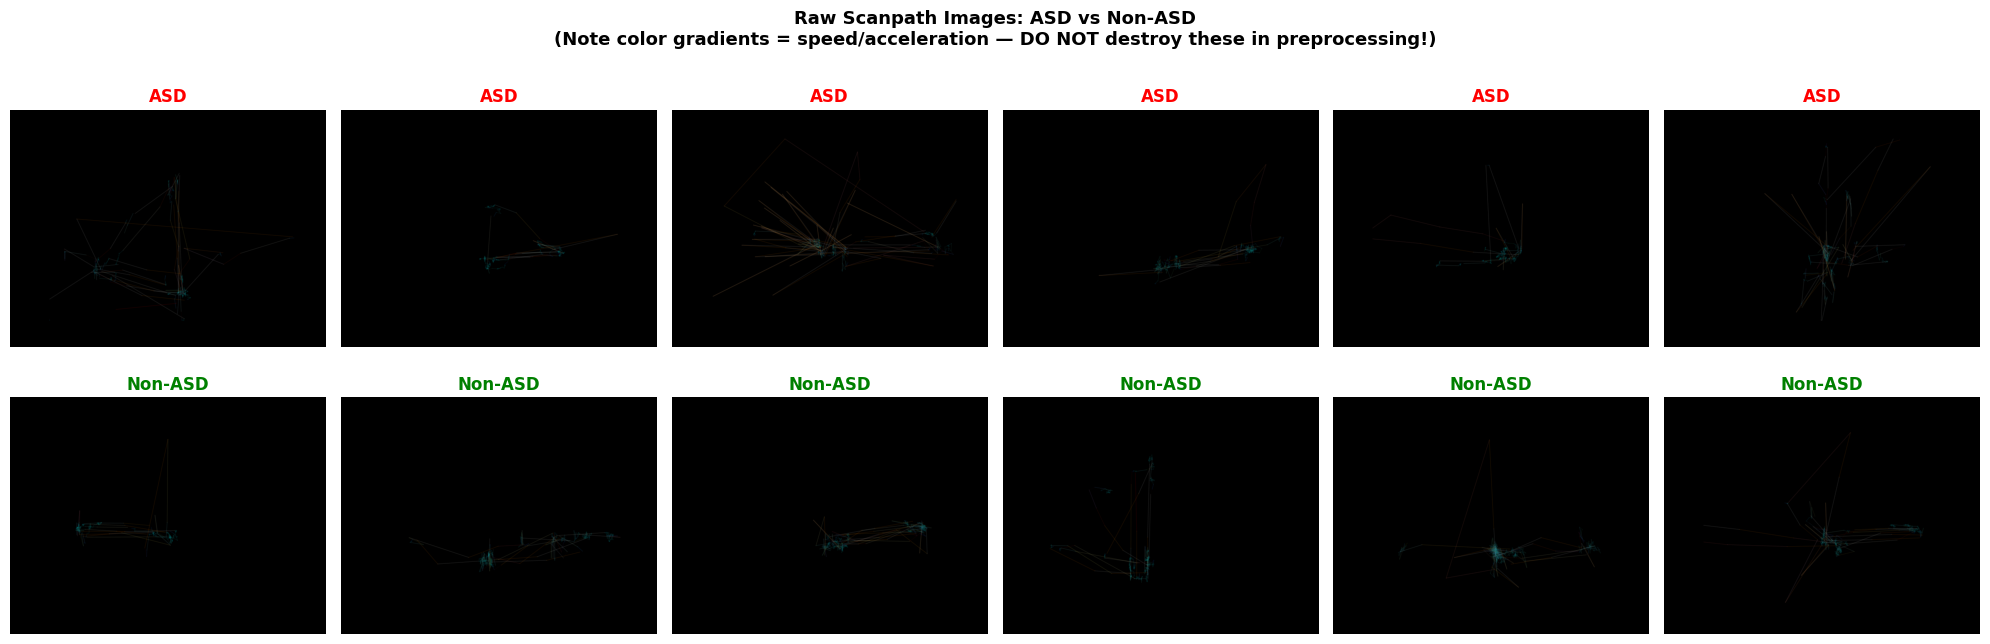


 Channel mean pixel values (should differ between ASD / Non-ASD):
  ASD: R=0.5  G=0.4  B=0.4
  Non-ASD: R=0.3  G=0.3  B=0.3


In [7]:
def load_raw(folder, n=6):
    files = random.sample(os.listdir(folder), min(n, len(os.listdir(folder))))
    imgs  = [cv2.cvtColor(cv2.imread(os.path.join(folder, f)), cv2.COLOR_BGR2RGB)
             for f in files if f.lower().endswith(('.png','.jpg','.jpeg'))]
    return imgs[:n]

asd_samples     = load_raw(ASD_DIR)
non_asd_samples = load_raw(NON_ASD_DIR)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle('Raw Scanpath Images: ASD vs Non-ASD\n'
             '(Note color gradients = speed/acceleration — DO NOT destroy these in preprocessing!)',
             fontsize=13, fontweight='bold')

for i, (img, ax) in enumerate(zip(asd_samples, axes[0])):
    ax.imshow(img); ax.set_title('ASD', color='red', fontweight='bold'); ax.axis('off')
for i, (img, ax) in enumerate(zip(non_asd_samples, axes[1])):
    ax.imshow(img); ax.set_title('Non-ASD', color='green', fontweight='bold'); ax.axis('off')

plt.tight_layout()
plt.savefig('/content/01_raw_samples.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Channel statistics ────────────────────────────────────────────────────────
print('\n Channel mean pixel values (should differ between ASD / Non-ASD):')
for label, imgs in [('ASD', asd_samples), ('Non-ASD', non_asd_samples)]:
    arr = np.stack([cv2.resize(i,(224,224)) for i in imgs])
    print(f'  {label}: R={arr[...,0].mean():.1f}  G={arr[...,1].mean():.1f}  B={arr[...,2].mean():.1f}')

## **Preprocessing:** The Correct Approach for Scanpath Images




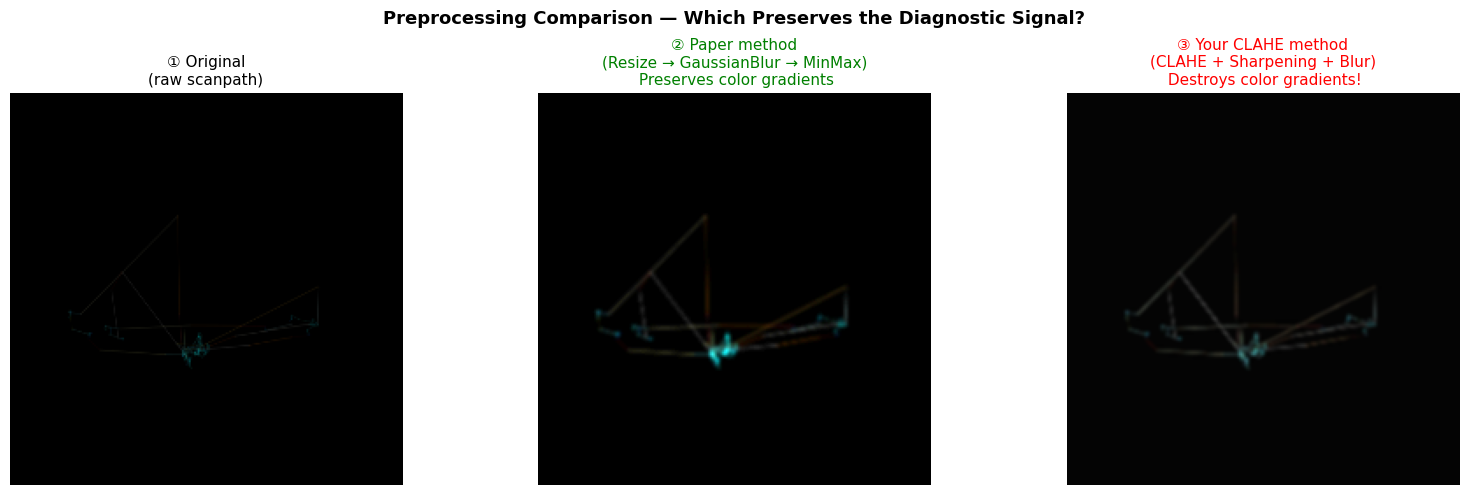


💡 The RED and GREEN channels carry velocity/acceleration info.
   CLAHE equalizes these channels → they become uniform → information LOST.


In [8]:
IMG_SIZE = (224, 224)

# ── Paper's preprocessing (correct for scanpath) ──────────────────────────────
def preprocess_paper(img_bgr):
    """Exactly what the paper describes."""
    img  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img  = cv2.resize(img, IMG_SIZE)
    img  = cv2.GaussianBlur(img, (5, 5), 0)          # light noise removal only
    img  = img.astype(np.float32)
    img  = (img - img.min()) / (img.max() - img.min() + 1e-8)  # min-max [0,1]
    return img

# ── Your current preprocessing (problematic) ──────────────────────────────────
def preprocess_clahe(img_bgr):
    """CLAHE + sharpening — destroys color gradients."""
    img = cv2.resize(img_bgr, IMG_SIZE)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l     = clahe.apply(l)
    img   = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)
    kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
    img   = cv2.filter2D(img, -1, kernel)
    img   = cv2.GaussianBlur(img, (5,5), 0)
    img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img   = img.astype(np.float32) / 255.0
    return img

# ── Visual comparison ─────────────────────────────────────────────────────────
sample_path = os.path.join(ASD_DIR, random.choice(asd_imgs))
raw_bgr     = cv2.imread(sample_path)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Preprocessing Comparison — Which Preserves the Diagnostic Signal?',
             fontsize=13, fontweight='bold')

axes[0].imshow(cv2.cvtColor(cv2.resize(raw_bgr, IMG_SIZE), cv2.COLOR_BGR2RGB))
axes[0].set_title('① Original\n(raw scanpath)', fontsize=11)
axes[0].axis('off')

axes[1].imshow(preprocess_paper(raw_bgr))
axes[1].set_title('② Paper method\n(Resize → GaussianBlur → MinMax)\n Preserves color gradients',
                  fontsize=11, color='green')
axes[1].axis('off')

axes[2].imshow(preprocess_clahe(raw_bgr))
axes[2].set_title('③ Your CLAHE method\n(CLAHE + Sharpening + Blur)\n Destroys color gradients!',
                  fontsize=11, color='red')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/content/02_preprocessing_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n💡 The RED and GREEN channels carry velocity/acceleration info.')
print('   CLAHE equalizes these channels → they become uniform → information LOST.')

##  CELL 5 — Load & Preprocess Dataset

In [9]:
def load_dataset(asd_dir, non_asd_dir, preprocess_fn):
    X, y = [], []
    valid_ext = ('.png', '.jpg', '.jpeg')

    for label, folder in [(1, asd_dir), (0, non_asd_dir)]:
        files = [f for f in os.listdir(folder) if f.lower().endswith(valid_ext)]
        for fname in files:
            path = os.path.join(folder, fname)
            bgr  = cv2.imread(path)
            if bgr is None:
                continue
            img = preprocess_fn(bgr)
            X.append(img)
            y.append(label)

    return np.array(X, dtype=np.float32), np.array(y)

print('Loading dataset with paper preprocessing...')
X_raw, y_raw = load_dataset(ASD_DIR, NON_ASD_DIR, preprocess_paper)

print(f'✅ Dataset loaded: {X_raw.shape}  (samples, H, W, C)')
print(f'   ASD={np.sum(y_raw==1)}  Non-ASD={np.sum(y_raw==0)}')
print(f'   Pixel range: [{X_raw.min():.3f}, {X_raw.max():.3f}]')

Loading dataset with paper preprocessing...
✅ Dataset loaded: (547, 224, 224, 3)  (samples, H, W, C)
   ASD=219  Non-ASD=328
   Pixel range: [0.000, 1.000]


## Data Augmentation

**augmentation 534 → ~3,761 images:**
- Small datasets → MobileNet/resnet features overfit
- Paper uses: random rotation (±15°), horizontal flip, vertical flip

**For scanpath images specifically:** Avoid color jitter (destroys gradient encoding). Use only geometric transforms.

Augmenting dataset...
✅ After augmentation: 2188 images
   ASD: 876  |  Non-ASD: 1312


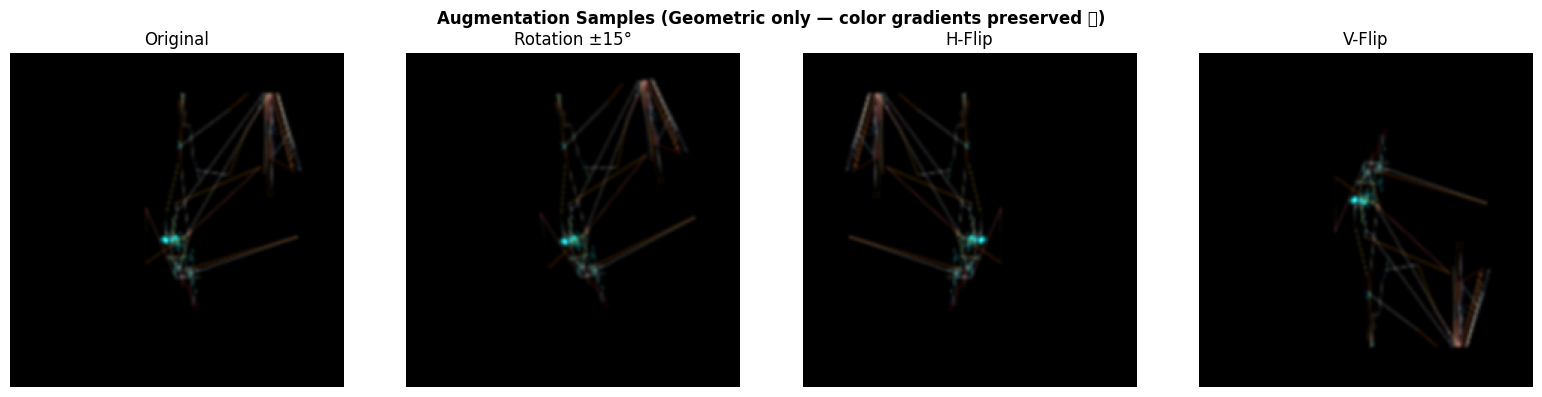

In [10]:
def augment_image(img):
    """Apply paper's augmentation: rotation ±15°, h-flip, v-flip.
    Returns 3 augmented versions (matches paper's ~4x increase)."""
    results = []

    # Random rotation ±15 degrees
    angle  = random.uniform(-15, 15)
    h, w   = img.shape[:2]
    M      = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    rot    = cv2.warpAffine((img*255).astype(np.uint8), M, (w,h))
    results.append(rot.astype(np.float32)/255.0)

    # Horizontal flip
    results.append(np.fliplr(img).copy())

    # Vertical flip
    results.append(np.flipud(img).copy())

    return results

def augment_dataset(X, y, aug_fn):
    X_aug, y_aug = list(X), list(y)
    for img, label in zip(X, y):
        for aug_img in aug_fn(img):
            X_aug.append(aug_img)
            y_aug.append(label)
    return np.array(X_aug, dtype=np.float32), np.array(y_aug)

print('Augmenting dataset...')
X_aug, y_aug = augment_dataset(X_raw, y_raw, augment_image)

print(f'✅ After augmentation: {X_aug.shape[0]} images')
print(f'   ASD: {np.sum(y_aug==1)}  |  Non-ASD: {np.sum(y_aug==0)}')

# ── Visualize augmentations ───────────────────────────────────────────────────
sample_idx = np.where(y_raw == 1)[0][0]
original   = X_raw[sample_idx]
augmented  = augment_image(original)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Augmentation Samples (Geometric only — color gradients preserved ✅)',
             fontweight='bold')
titles = ['Original', 'Rotation ±15°', 'H-Flip', 'V-Flip']
for ax, img, title in zip(axes, [original]+augmented, titles):
    ax.imshow(img); ax.set_title(title); ax.axis('off')
plt.tight_layout()
plt.savefig('/content/03_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()

## ✂️ CELL 7 — Stratified Train/Test Split (80:20)

Train: 1750 images  (ASD=701, Non-ASD=1049)
Test : 438  images  (ASD=175, Non-ASD=263)


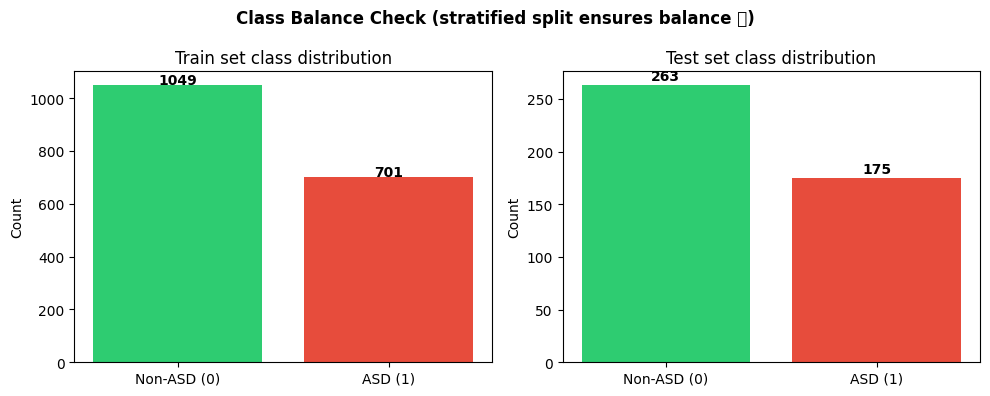

In [11]:
# Shuffle first, then split
indices  = np.arange(len(X_aug))
np.random.shuffle(indices)
X_shuf, y_shuf = X_aug[indices], y_aug[indices]

X_train, X_test, y_train, y_test = train_test_split(
    X_shuf, y_shuf,
    test_size=0.20,
    stratify=y_shuf,
    random_state=SEED
)

print(f'Train: {X_train.shape[0]} images  (ASD={np.sum(y_train==1)}, Non-ASD={np.sum(y_train==0)})')
print(f'Test : {X_test.shape[0]}  images  (ASD={np.sum(y_test==1)}, Non-ASD={np.sum(y_test==0)})')

# Class balance bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y, title in zip(axes, [y_train, y_test], ['Train', 'Test']):
    counts = Counter(y)
    ax.bar(['Non-ASD (0)', 'ASD (1)'], [counts[0], counts[1]],
           color=['#2ecc71','#e74c3c'])
    ax.set_title(f'{title} set class distribution')
    ax.set_ylabel('Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v+5, str(v), ha='center', fontweight='bold')
plt.suptitle('Class Balance Check (stratified split ensures balance ✅)', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/04_class_balance.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Extraction: MobileNet (Paper Method)

**Key configuration details from the paper:**
- `include_top=False` → remove classification head
- `trainable=False` → freeze ALL layers (pure feature extractor)
- Use ImageNet weights
- Apply MobileNet's own `preprocess_input` (scales to [-1, 1])

In [12]:
def build_feature_extractor(model_name='mobilenet'):
    """Build frozen feature extractor. model_name: 'mobilenet' or 'resnet50'."""
    if model_name == 'mobilenet':
        base   = MobileNet(weights='imagenet', include_top=False,
                           input_shape=(224, 224, 3), pooling='avg')
        preproc = mobilenet_preprocess
    elif model_name == 'resnet50':
        base   = ResNet50(weights='imagenet', include_top=False,
                          input_shape=(224, 224, 3), pooling='avg')
        preproc = resnet_preprocess

    base.trainable = False  # Freeze ALL layers — pure extractor
    model = Model(inputs=base.input, outputs=base.output)
    print(f'✅ {model_name} feature extractor | Output shape: {model.output_shape}')
    print(f'   Trainable params: {sum(w.numpy().size for w in model.trainable_weights):,}')
    return model, preproc

def extract_features(model, preproc_fn, images, batch_size=32):
    """Extract features in batches."""
    features = []
    for i in range(0, len(images), batch_size):
        batch = images[i:i+batch_size]
        # Convert [0,1] float → [0,255] uint8 → model-specific preprocessing
        batch_uint8 = (batch * 255).astype(np.uint8)
        batch_prep  = preproc_fn(batch_uint8.astype(np.float32))
        feat        = model.predict(batch_prep, verbose=0)
        features.append(feat)
        if (i // batch_size) % 10 == 0:
            print(f'  Batch {i//batch_size+1}/{(len(images)-1)//batch_size+1}', end='\r')
    return np.vstack(features)

# ── Extract with MobileNet ────────────────────────────────────────────────────
print('Building MobileNet extractor...')
mobile_model, mobile_preproc = build_feature_extractor('mobilenet')

print('\nExtracting train features...')
X_train_feat = extract_features(mobile_model, mobile_preproc, X_train)
print('\nExtracting test features...')
X_test_feat  = extract_features(mobile_model, mobile_preproc, X_test)

print(f'\n✅ Feature shapes — Train: {X_train_feat.shape}  Test: {X_test_feat.shape}')

Building MobileNet extractor...
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ mobilenet feature extractor | Output shape: (None, 1024)
   Trainable params: 0

Extracting train features...

Extracting test features...

✅ Feature shapes — Train: (1750, 1024)  Test: (438, 1024)


##  PCA Dimensionality Reduction

**Paper uses 250 components.** This cell also plots explained variance so we can tune this number.

Fitting PCA with 250 components...
✅ PCA complete: 250 components explain 92.1% variance
   Shape: 1024D → 250D


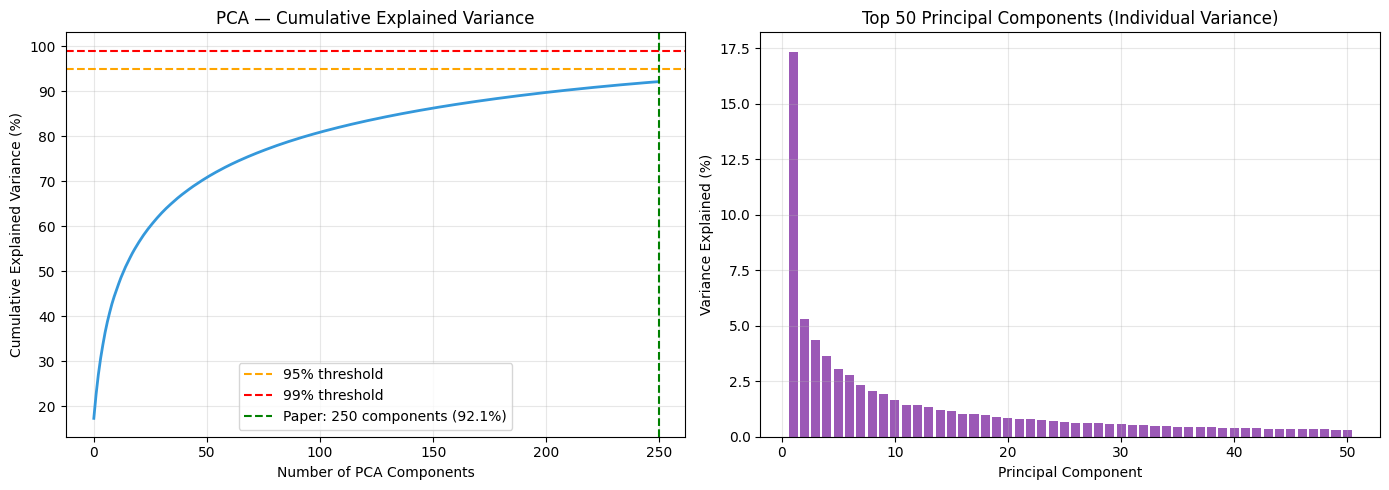


💡 Components for 95% variance: 251
   Components for 99% variance: 251
   Paper uses: 250 components  → 92.1% variance


In [13]:
N_COMPONENTS = 250  # Paper setting

print(f'Fitting PCA with {N_COMPONENTS} components...')
pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
pca.fit(X_train_feat)

X_train_pca = pca.transform(X_train_feat)
X_test_pca  = pca.transform(X_test_feat)

variance_explained = np.sum(pca.explained_variance_ratio_) * 100
print(f'✅ PCA complete: {N_COMPONENTS} components explain {variance_explained:.1f}% variance')
print(f'   Shape: {X_train_feat.shape[1]}D → {X_train_pca.shape[1]}D')

# ── Explained variance plot ───────────────────────────────────────────────────
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cumvar, color='#3498db', linewidth=2)
axes[0].axhline(95, color='orange', linestyle='--', label='95% threshold')
axes[0].axhline(99, color='red',    linestyle='--', label='99% threshold')
axes[0].axvline(N_COMPONENTS, color='green', linestyle='--',
                label=f'Paper: {N_COMPONENTS} components ({variance_explained:.1f}%)')
axes[0].set_xlabel('Number of PCA Components')
axes[0].set_ylabel('Cumulative Explained Variance (%)')
axes[0].set_title('PCA — Cumulative Explained Variance')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(range(1, 51), pca.explained_variance_ratio_[:50]*100, color='#9b59b6')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Top 50 Principal Components (Individual Variance)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/05_pca_variance.png', dpi=120, bbox_inches='tight')
plt.show()

# Find components needed for 95% and 99%
n_95 = np.searchsorted(cumvar, 95) + 1
n_99 = np.searchsorted(cumvar, 99) + 1
print(f'\n💡 Components for 95% variance: {n_95}')
print(f'   Components for 99% variance: {n_99}')
print(f'   Paper uses: 250 components  → {variance_explained:.1f}% variance')

## Stacking Ensemble Classifier

**Exact paper configuration:**
- Base model 1: SVM with `kernel='poly'`, `coef0=1.5`, `degree=4`, `random_state=42`
- Base model 2: KNN with `n_neighbors=3`
- Meta model: Logistic Regression
- Cross-validation: `cv=5`


In [14]:
# ── Define base models (paper exact settings) ─────────────────────────────────
svm_base = SVC(
    kernel='poly',
    coef0=1.5,
    degree=4,
    random_state=SEED,
    probability=True    # Required for stacking
)

knn_base = KNeighborsClassifier(
    n_neighbors=3       # Paper uses k=3
)

# ── Meta model ────────────────────────────────────────────────────────────────
meta_lr = LogisticRegression(
    max_iter=1000,
    random_state=SEED
)

# ── Stacking ensemble ─────────────────────────────────────────────────────────
stacking_clf = StackingClassifier(
    estimators=[('svm', svm_base), ('knn', knn_base)],
    final_estimator=meta_lr,
    cv=5,               # Paper's K-fold = 5
    passthrough=False,
    n_jobs=-1
)

print('Training Stacking Ensemble (SVM + KNN → Logistic Regression)...')
print('This may take 3–10 minutes depending on dataset size...')
stacking_clf.fit(X_train_pca, y_train)
print('✅ Training complete!')

Training Stacking Ensemble (SVM + KNN → Logistic Regression)...
This may take 3–10 minutes depending on dataset size...
✅ Training complete!


##  Evaluation: All Metrics + Confusion Matrix


  📊 MobileNet + Stacking Ensemble Results
  Accuracy    : 92.69%   (Paper: ~98.0%)
  Precision   : 90.86%   (Paper: ~98.4%)
  Sensitivity : 90.86%   (Paper: ~98.2%)
  Specificity : 93.92%   (Paper: ~97.8%)
  F1-Score    : 90.86%


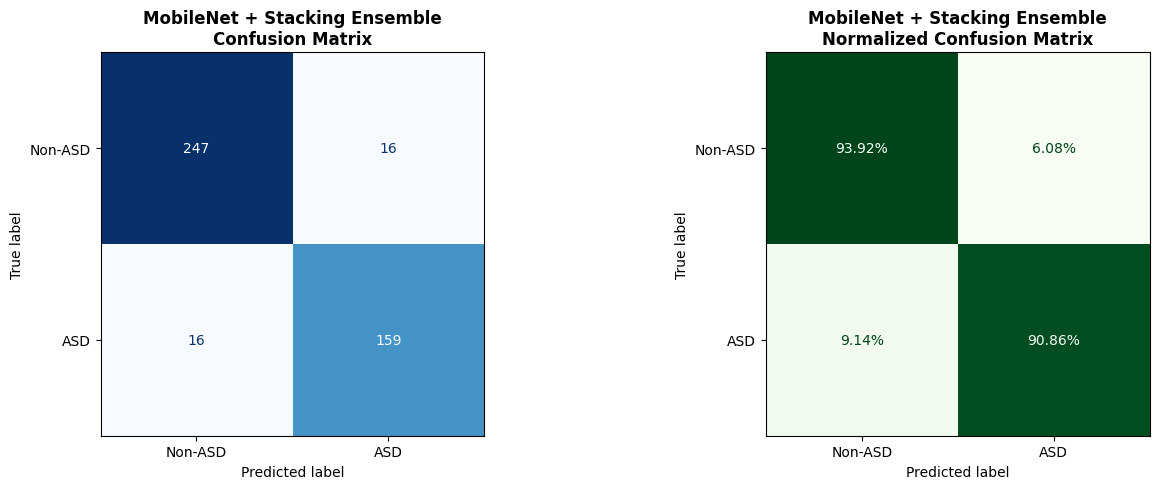

In [15]:
def evaluate_model(clf, X_test, y_test, model_name='Model'):
    """Compute and display all paper metrics."""
    y_pred = clf.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)  * 100
    prec = precision_score(y_test, y_pred) * 100
    rec  = recall_score(y_test, y_pred)    * 100   # = Sensitivity
    f1   = f1_score(y_test, y_pred)        * 100

    # Specificity = TN / (TN + FP)
    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) * 100

    print(f'\n{'='*55}')
    print(f'  📊 {model_name} Results')
    print(f'{'='*55}')
    print(f'  Accuracy    : {acc:.2f}%   (Paper: ~98.0%)')
    print(f'  Precision   : {prec:.2f}%   (Paper: ~98.4%)')
    print(f'  Sensitivity : {rec:.2f}%   (Paper: ~98.2%)')
    print(f'  Specificity : {spec:.2f}%   (Paper: ~97.8%)')
    print(f'  F1-Score    : {f1:.2f}%')
    print(f'{'='*55}')

    # Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ConfusionMatrixDisplay(cm, display_labels=['Non-ASD','ASD']).plot(
        ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')

    # Normalized confusion matrix
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    ConfusionMatrixDisplay(cm_norm, display_labels=['Non-ASD','ASD']).plot(
        ax=axes[1], colorbar=False, cmap='Greens', values_format='.2%')
    axes[1].set_title(f'{model_name}\nNormalized Confusion Matrix', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'/content/06_confusion_{model_name.lower().replace(" ","_")}.png',
                dpi=120, bbox_inches='tight')
    plt.show()

    return {'Accuracy': acc, 'Precision': prec, 'Sensitivity': rec,
            'Specificity': spec, 'F1': f1}

results_stack = evaluate_model(stacking_clf, X_test_pca, y_test,
                               'MobileNet + Stacking Ensemble')

## 🔄 CELL 12 — ResNet50 Alternative (Compare with MobileNet)

Building ResNet50 extractor...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ resnet50 feature extractor | Output shape: (None, 2048)
   Trainable params: 0
Extracting ResNet50 features...
Applying PCA...
Training stacking classifier on ResNet50 features...

  📊 ResNet50 + Stacking Ensemble Results
  Accuracy    : 92.69%   (Paper: ~98.0%)
  Precision   : 89.50%   (Paper: ~98.4%)
  Sensitivity : 92.57%   (Paper: ~98.2%)
  Specificity : 92.78%   (Paper: ~97.8%)
  F1-Score    : 91.01%


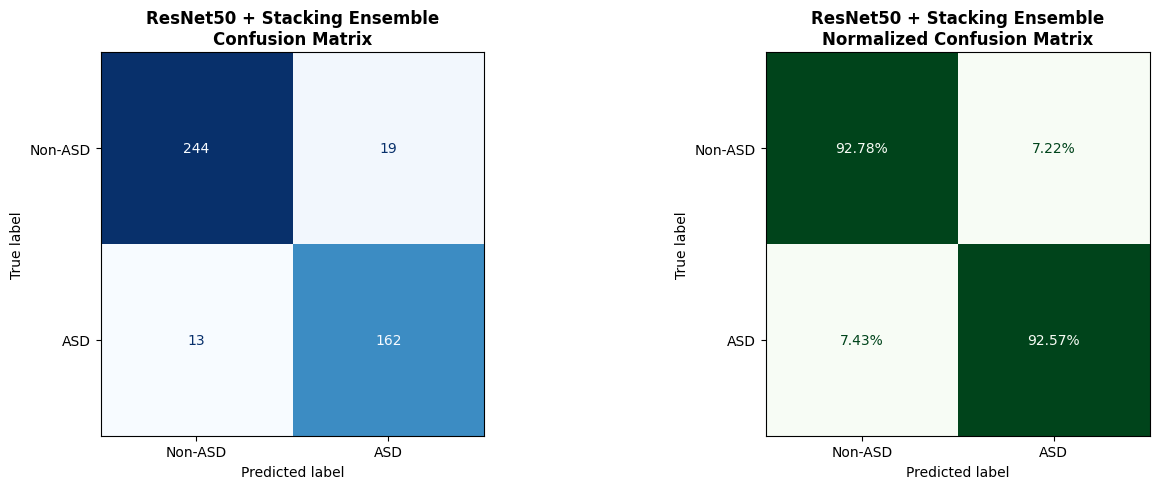

In [16]:
print('Building ResNet50 extractor...')
resnet_model, resnet_preproc = build_feature_extractor('resnet50')

print('Extracting ResNet50 features...')
X_train_resnet = extract_features(resnet_model, resnet_preproc, X_train)
X_test_resnet  = extract_features(resnet_model, resnet_preproc, X_test)

print('Applying PCA...')
pca_resnet = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_train_r_pca = pca_resnet.fit_transform(X_train_resnet)
X_test_r_pca  = pca_resnet.transform(X_test_resnet)

print('Training stacking classifier on ResNet50 features...')
from sklearn.base import clone
stacking_resnet = clone(stacking_clf)
stacking_resnet.fit(X_train_r_pca, y_train)

results_resnet = evaluate_model(stacking_resnet, X_test_r_pca, y_test,
                                'ResNet50 + Stacking Ensemble')

## Individual Model Comparison (SVM-only vs KNN-only vs Stacking)

  MobileNet+SVM: Accuracy = 92.69%
  MobileNet+KNN: Accuracy = 90.41%
  MobileNet+Stacking: Accuracy = 92.69%


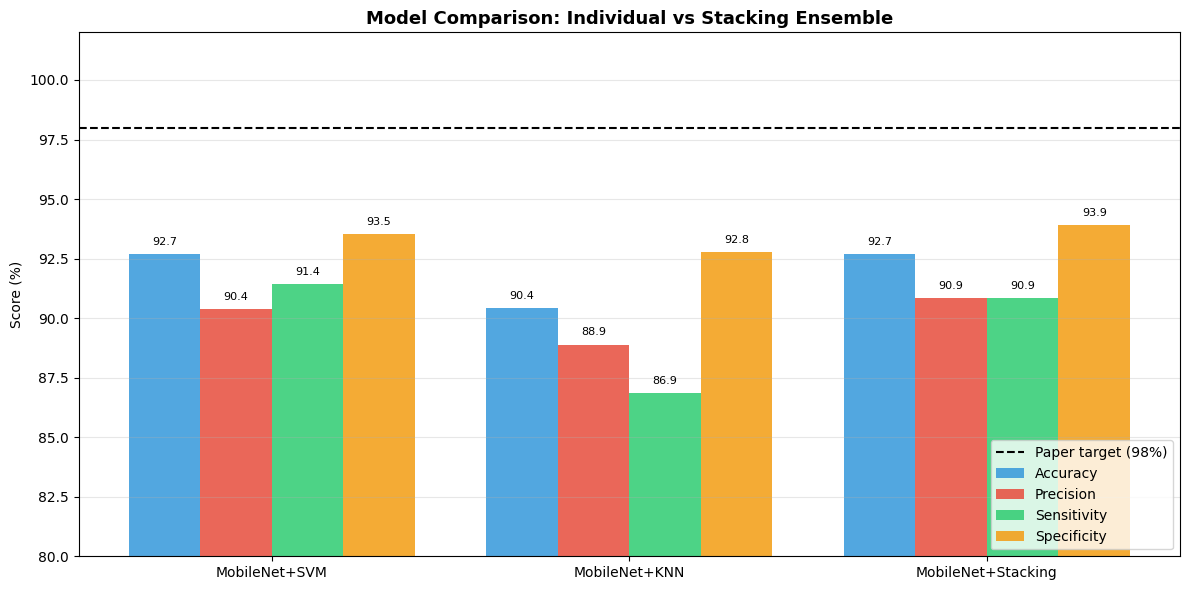

In [17]:
# ── Train individual models for comparison ────────────────────────────────────
models_compare = {
    'MobileNet+SVM':      SVC(kernel='poly', coef0=1.5, degree=4, random_state=SEED),
    'MobileNet+KNN':      KNeighborsClassifier(n_neighbors=3),
    'MobileNet+Stacking': stacking_clf   # already trained
}

comparison_results = {}
for name, clf in models_compare.items():
    if name != 'MobileNet+Stacking':
        clf.fit(X_train_pca, y_train)
    y_pred = clf.predict(X_test_pca)
    acc  = accuracy_score(y_test, y_pred) * 100
    cm   = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    comparison_results[name] = {
        'Accuracy': acc,
        'Precision': precision_score(y_test, y_pred)*100,
        'Sensitivity': recall_score(y_test, y_pred)*100,
        'Specificity': tn/(tn+fp)*100
    }
    print(f'  {name}: Accuracy = {acc:.2f}%')

# ── Comparison chart ─────────────────────────────────────────────────────────
df_compare = pd.DataFrame(comparison_results).T

fig, ax = plt.subplots(figsize=(12, 6))
x   = np.arange(len(df_compare))
w   = 0.2
cols= ['Accuracy','Precision','Sensitivity','Specificity']
colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']

for i, (col, color) in enumerate(zip(cols, colors)):
    bars = ax.bar(x + i*w, df_compare[col], w, label=col, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

# Paper reference line
ax.axhline(98.0, color='black', linestyle='--', linewidth=1.5, label='Paper target (98%)')

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(df_compare.index, fontsize=10)
ax.set_ylabel('Score (%)')
ax.set_ylim(80, 102)
ax.set_title('Model Comparison: Individual vs Stacking Ensemble', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/07_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

##  Final Comparison Table vs Paper


  FINAL COMPARISON: Our Pipeline vs Published Paper
                Accuracy  Precision  Sensitivity  Specificity
Paper (ETSDS)  98.000000  98.400000    98.200000     97.80000
Our Result     92.694064  90.857143    90.857143     93.91635

📉 Gap Analysis:
  ❌ Accuracy: +5.31% gap
  ❌ Precision: +7.54% gap
  ❌ Sensitivity: +7.34% gap
  ❌ Specificity: +3.88% gap


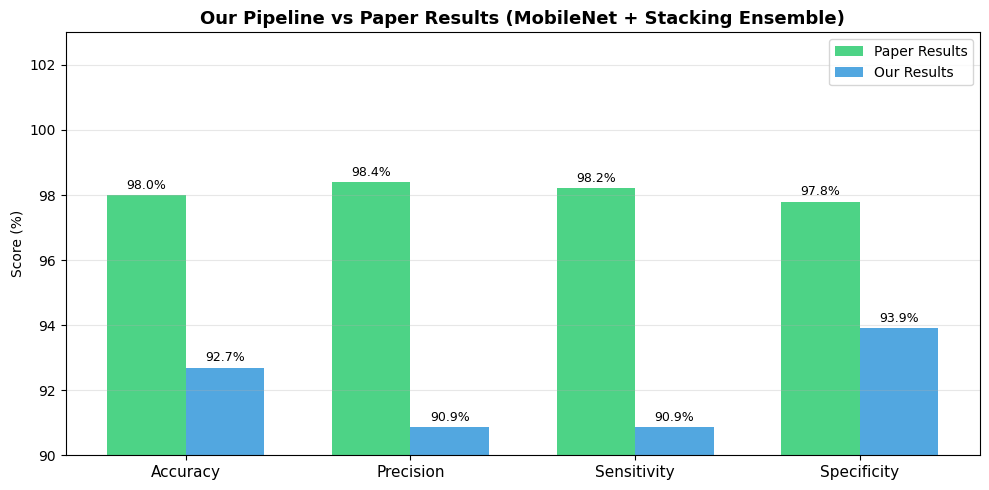

In [18]:
paper_results = {
    'Accuracy': 98.0, 'Precision': 98.4,
    'Sensitivity': 98.2, 'Specificity': 97.8
}

our_best = comparison_results['MobileNet+Stacking']

compare_df = pd.DataFrame({
    'Paper (ETSDS)': paper_results,
    'Our Result':    our_best
}).T

print('\n' + '='*65)
print('  FINAL COMPARISON: Our Pipeline vs Published Paper')
print('='*65)
print(compare_df.to_string())
print('='*65)

# Gap analysis
print('\n📉 Gap Analysis:')
for metric in paper_results:
    gap = paper_results[metric] - our_best[metric]
    icon = '✅' if gap <= 1.0 else ('⚠️' if gap <= 3.0 else '❌')
    print(f'  {icon} {metric}: {gap:+.2f}% gap')

# ── Bar chart final comparison ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
x   = np.arange(4)
w   = 0.35
metrics = list(paper_results.keys())

bars1 = ax.bar(x-w/2, list(paper_results.values()), w,
               label='Paper Results', color='#2ecc71', alpha=0.85)
bars2 = ax.bar(x+w/2, [our_best[m] for m in metrics], w,
               label='Our Results', color='#3498db', alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_ylim(90, 103)
ax.set_title('Our Pipeline vs Paper Results (MobileNet + Stacking Ensemble)',
             fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/08_final_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

##  Hyperparameter Tuning Experiments
Testing PCA components, SVM coef0, and KNN k values.

In [19]:
print('Experiment A: Effect of PCA components')
print('-'*50)
pca_results = {}
for n_comp in [100, 150, 200, 250, 300]:
    p = PCA(n_components=min(n_comp, X_train_feat.shape[1]), random_state=SEED)
    Xtr = p.fit_transform(X_train_feat)
    Xte = p.transform(X_test_feat)
    clf = StackingClassifier(
        estimators=[('svm', SVC(kernel='poly',coef0=1.5,degree=4,random_state=SEED,probability=True)),
                    ('knn', KNeighborsClassifier(n_neighbors=3))],
        final_estimator=LogisticRegression(max_iter=1000,random_state=SEED),
        cv=5, n_jobs=-1
    )
    clf.fit(Xtr, y_train)
    acc = accuracy_score(y_test, clf.predict(Xte)) * 100
    pca_results[n_comp] = acc
    print(f'  PCA={n_comp:3d} components → Accuracy: {acc:.2f}%')

best_n = max(pca_results, key=pca_results.get)
print(f'\n✅ Best PCA components: {best_n} ({pca_results[best_n]:.2f}%)')

print('\nExperiment B: Effect of KNN k value')
print('-'*50)
for k in [3, 5, 7]:
    clf = StackingClassifier(
        estimators=[('svm', SVC(kernel='poly',coef0=1.5,degree=4,random_state=SEED,probability=True)),
                    ('knn', KNeighborsClassifier(n_neighbors=k))],
        final_estimator=LogisticRegression(max_iter=1000,random_state=SEED),
        cv=5, n_jobs=-1
    )
    clf.fit(X_train_pca, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test_pca)) * 100
    print(f'  KNN k={k} → Accuracy: {acc:.2f}%')

print('\nExperiment C: Effect of SVM coef0')
print('-'*50)
for coef in [0.0, 1.5, 2.5]:
    clf = StackingClassifier(
        estimators=[('svm', SVC(kernel='poly',coef0=coef,degree=4,random_state=SEED,probability=True)),
                    ('knn', KNeighborsClassifier(n_neighbors=3))],
        final_estimator=LogisticRegression(max_iter=1000,random_state=SEED),
        cv=5, n_jobs=-1
    )
    clf.fit(X_train_pca, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test_pca)) * 100
    print(f'  SVM coef0={coef} → Accuracy: {acc:.2f}%')

Experiment A: Effect of PCA components
--------------------------------------------------
  PCA=100 components → Accuracy: 93.38%
  PCA=150 components → Accuracy: 92.47%
  PCA=200 components → Accuracy: 92.47%
  PCA=250 components → Accuracy: 92.69%
  PCA=300 components → Accuracy: 93.38%

✅ Best PCA components: 100 (93.38%)

Experiment B: Effect of KNN k value
--------------------------------------------------
  KNN k=3 → Accuracy: 92.69%
  KNN k=5 → Accuracy: 92.92%
  KNN k=7 → Accuracy: 92.92%

Experiment C: Effect of SVM coef0
--------------------------------------------------
  SVM coef0=0.0 → Accuracy: 92.69%
  SVM coef0=1.5 → Accuracy: 92.69%
  SVM coef0=2.5 → Accuracy: 92.24%


##  Save Trained Model & Results

In [20]:
import joblib

SAVE_DIR = '/content/drive/MyDrive/ASD_Model_Outputs'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save pipeline components
joblib.dump(pca,          f'{SAVE_DIR}/pca_250.pkl')
joblib.dump(stacking_clf, f'{SAVE_DIR}/stacking_clf.pkl')

# Save results CSV
results_df = pd.DataFrame({
    'Model':       ['MobileNet+SVM', 'MobileNet+KNN', 'MobileNet+Stacking', 'Paper Target'],
    'Accuracy':    [comparison_results['MobileNet+SVM']['Accuracy'],
                    comparison_results['MobileNet+KNN']['Accuracy'],
                    results_stack['Accuracy'], 98.0],
    'Precision':   [comparison_results['MobileNet+SVM']['Precision'],
                    comparison_results['MobileNet+KNN']['Precision'],
                    results_stack['Precision'], 98.4],
    'Sensitivity': [comparison_results['MobileNet+SVM']['Sensitivity'],
                    comparison_results['MobileNet+KNN']['Sensitivity'],
                    results_stack['Sensitivity'], 98.2],
    'Specificity': [comparison_results['MobileNet+SVM']['Specificity'],
                    comparison_results['MobileNet+KNN']['Specificity'],
                    results_stack['Specificity'], 97.8],
})

results_df.to_csv(f'{SAVE_DIR}/results.csv', index=False)

# Save all figures to Drive
import shutil
for fig_file in [f for f in os.listdir('/content') if f.endswith('.png')]:
    shutil.copy(f'/content/{fig_file}', f'{SAVE_DIR}/{fig_file}')

print(f'✅ All outputs saved to: {SAVE_DIR}')
print('\nSaved files:')
for f in os.listdir(SAVE_DIR):
    print(f'   {f}')

✅ All outputs saved to: /content/drive/MyDrive/ASD_Model_Outputs

Saved files:
   pca_250.pkl
   stacking_clf.pkl
   results.csv
   01_raw_samples.png
   06_confusion_mobilenet_+_stacking_ensemble.png
   08_final_comparison.png
   02_preprocessing_comparison.png
   05_pca_variance.png
   06_confusion_resnet50_+_stacking_ensemble.png
   07_model_comparison.png
   04_class_balance.png
   03_augmentation.png
